# Notebook to setup the radcalnet_oc package

In [1]:

import os, shutil
import glob

import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
rc = {"font.family": "serif",
      "mathtext.fontset": "stix"}
plt.rcParams.update(rc)
plt.rcParams["font.serif"] = ["Times New Roman"] + plt.rcParams["font.serif"]

plt.rcParams.update({'font.size': 18, 'axes.labelsize': 22})
import numpy as np
import xarray as xr
import pandas as pd
import datetime as dt

import radcalnet_oc as radoc

opj = os.path.join

print(f'-radcalnet_oc: {radoc.__version__}')


-radcalnet_oc: 0.0.2


In [2]:

sites = ['Abu_Al_Bukhoosh', 'ARIAKE_TOWER', 'Bahia_Blanca', 'Banana_River',
       'Bari_Waterfront', 'Blyth_NOAH', 'Casablanca_Platform',
       'Chesapeake_Bay', 'COVE_SEAPRISM', 'Gageocho_Station',
       'Galata_Platform', 'Gloria', 'Gotland', 'GOT_Seaprism', 'Grizzly_Bay',
       'Gustav_Dalen_Tower', 'HBOI', 'Helsinki_Lighthouse', 'Ieodo_Station',
       'Irbe_Lighthouse', 'KAUST_Campus', 'Kemigawa_Offshore', 'Lake_Erie',
       'Lake_Okeechobee', 'Lake_Okeechobee_N', 'LISCO', 'Lucinda', 'MVCO',
       'Palgrunden', 'PLOCAN_Tower', 'RdP-EsNM', 'Sacramento_River',
       'San_Marco_Platform', 'Section-7_Platform', 'Socheongcho',
       'South_Greenbay', 'Thornton_C-power', 'USC_SEAPRISM', 'USC_SEAPRISM_2',
       'Venise', 'WaveCIS_Site_CSI_6', 'Zeebrugge-MOW1']
bandIds = range(13)
resolution = 20
width, height = 5000, 5000
complevel=5
datadir = '/data/satellite/Sentinel-2/L1C/'
odir = '/data/radcalnet/data_v0.0.2'

info = pd.read_csv('/DATA/AERONET/info_aeronet_oc_v15_location.csv',index_col=0)
xinfo = info.to_xarray()
info

,start_date,end_date,number,latitude,longitude,s2_tile
site,,,,,,
Abu_Al_Bukhoosh,2015-07-01,2015-07-01,0,25.495000,53.145833,39RYJ
ARIAKE_TOWER,2018-02-23,2023-03-19,2001,33.103617,130.271950,52SFB
Bahia_Blanca,2020-01-23,2024-09-03,4936,-39.148000,-61.722000,20HPB
Banana_River,2022-06-16,2025-01-25,2006,28.367000,-80.633000,17RNM
Bari_Waterfront,2015-07-01,2015-07-01,0,41.116800,16.893400,33TXF
Blyth_NOAH,2016-04-21,2017-09-19,33,55.146399,-1.420859,30UWG
Casablanca_Platform,2019-04-02,2025-03-31,18735,40.717000,1.358000,31TCF
Chesapeake_Bay,2021-10-07,2025-03-31,12554,39.124000,-76.359000,18SUJ
COVE_SEAPRISM,2015-11-15,2016-01-09,163,36.900000,-75.710000,18SVF


### Select site and level of AERONET-OC data

In [3]:
site= 'Galata_Platform' # 'Venise' # 'Lucinda'
level='lev20'
info_ = xinfo.sel(site=site)
tile =  str(info_.s2_tile.values)
clon,clat = info_.longitude.values,info_.latitude.values
print(tile,clon,clat)
aeronet_oc = xr.open_mfdataset(opj('/DATA/AERONET/netcdf/OCv3',level,site+'*'+level+'.nc')).load().sel(time=slice('2017','2024')).sortby('wl')

hyp_aeronet_oc = xr.open_mfdataset(opj('/DATA/AERONET/OCv3_invRrs/data',site,level,site+'*v2.nc'))
# convert nan to zero
hyp_aeronet_oc = hyp_aeronet_oc.fillna(0)
hyp_aeronet_oc.load()

35TNH 28.19319 43.044624


<xarray.Dataset> Size: 24MB
Dimensions:    (time: 7582, wl: 200)
Coordinates:
  * time       (time) datetime64[ns] 61kB 2017-01-02T08:22:55 ... 2023-01-01T...
  * wl         (wl) float64 2kB 350.0 353.8 357.5 ... 1.096e+03 1.1e+03
Data variables:
    Rrs        (time, wl) float64 12MB 0.00341 0.00358 0.003759 ... 0.0 0.0 0.0
    Rrs_nadir  (time, wl) float64 12MB 0.003037 0.003189 0.003349 ... 0.0 0.0
Attributes:
    description:  InvRrs generated hyperspectral Rrs from multispectral AERON...

In [4]:
hyp_aeronet_oc.Rrs.attrs = {'unit':'sr-1',
                           'long name': 'remoate sensing reflectance',
                           'description': 'hyperspectral Rrs generated be the InvRrs package from multispectral AERONET-OC data' }

### Get input parameters from AERONET-OC data set

In [5]:
aeronet_oc

<xarray.Dataset> Size: 22MB
Dimensions:                       (time: 7586, wl: 14)
Coordinates:
  * time                          (time) datetime64[ns] 61kB 2017-01-02T08:22...
  * wl                            (wl) float64 112B 400.0 412.0 ... 1.02e+03
Data variables: (12/45)
    Aerosol_Optical_Depth         (time, wl) float64 850kB nan ... 0.03571
    wavelength                    (time, wl) float64 850kB nan 0.4125 ... 1.02
    Li_mean                       (time, wl) float64 850kB nan 4.85 ... 0.1512
    Li_stddev                     (time, wl) float64 850kB nan ... 0.00021
    Lt_mean                       (time, wl) float64 850kB nan ... 0.00615
    Lt_min_rel                    (time, wl) float64 850kB nan ... 0.004902
    ...                            ...
    year                          (time) int64 61kB 2017 2017 2017 ... 2023 2023
    season                        (time) <U3 91kB 'DJF' 'DJF' ... 'DJF' 'DJF'
    Rrs_Lw                        (time, wl) float64 850kB nan ... 9.722e-06
    Rrs_Lwn                       (time, wl) float64 850kB nan ... 2.466e-05
    Rrs_Lwn_IOP                   (time, wl) float64 850kB nan ... 2.466e-05
    Rrs_Lwn_fQ                    (time, wl) float64 850kB nan ... 2.466e-05

In [6]:
## Convert gas concentration into kg m-2
# tcwv cm into kg.m-2
tpw_cm=aeronet_oc['Total_Precipitable_Water(cm)']
aeronet_oc['tcwv']=tpw_cm*10 
aeronet_oc['tcwv'].attrs = {'unit':'kg.m-2',
                            'description': 'vertically integrated concentration of water vapor',
                            'long name':'total column of water vapor'}

# conversion DU to kg.m-2
to3_du=aeronet_oc['Total_Ozone(Du)'] 
aeronet_oc['tco3']=to3_du *2.14485e-5
aeronet_oc['tco3'].attrs = {'unit':'kg.m-2',
                            'description': 'vertically integrated concentration of ozone',
                            'long name':'total column of ozone'}

tcno2_du = aeronet_oc['Total_NO2(DU)']
aeronet_oc['tcno2']=tcno2_du*2.055482e-5
aeronet_oc['tcno2'].attrs = {'unit':'kg.m-2',
                            'description': 'vertically integrated concentration of nitrogen dioxide',
                            'long name':'total column of NO2 '}

aeronet_oc['pressure']=aeronet_oc['Pressure(hPa)']
aeronet_oc['pressure'].attrs = {'unit':'hPa',
                                'long name': 'atmospheric pressure at site level'}

aeronet_oc['sza']=aeronet_oc['SZA']
aeronet_oc['sza'].attrs['unit']='degree'
aeronet_oc['sza'].attrs['long name']='solar zenith angle'

aeronet_oc['day_of_year']=aeronet_oc['Day_of_Year']


# to make sure that AOT is available at 550nm
aeronet_oc['aot550'] = aeronet_oc['Aerosol_Optical_Depth'].interpolate_na(dim='wl').interp(wl=550)
aeronet_oc['aot550'].attrs = {'unit':'-',
                              'description': 'aerosol optical thickness measured from direct sun extinction from the AERONET CIMEL sytem',
                              'long name':'aerosol optical thickness at 550 nm'}

aeronet_oc['aot865'] = aeronet_oc['Aerosol_Optical_Depth'].interpolate_na('wl').interp(wl=865)
aeronet_oc['aot865'].attrs = {'unit':'-',
                              'description': 'aerosol optical thickness measured from direct sun extinction from the AERONET CIMEL sytem',
                              'long name':'aerosol optical thickness at 865 nm'}


# get normalizedt AOT for aerosol models retrieval
aeronet_oc['naot'] = aeronet_oc['Aerosol_Optical_Depth']/aeronet_oc['aot550']
aeronet_oc['naot'].attrs = {'unit':'-','description': 'spectral aerosol optical thickness normalized by its value at 550 nm'}
# get values for the Angstrom exponent
aeronet_oc['ang_exp'] = -(np.log(aeronet_oc['aot550']/aeronet_oc['aot865'])/np.log(550/865))# to make sure that AOT is available at 550nm
aeronet_oc['ang_exp'].attrs = {'unit':'-',
                              'description': 'angstrom exponent computed between 550 nm and 865 nm',
                              'long name':'angstrom exponent'}

aeronet_oc['Rrs_Lwn'].attrs = {'unit':'sr-1',
                              'description': 'remote sensing reflectance from AERONET-OC parameter Lwn without anisotropy correction',
                              'long name':'remote sensing reflectance from Lwn'}

aeronet_oc['Rrs_Lwn_IOP'].attrs = {'unit':'sr-1',
                              'description': 'remote sensing reflectance from AERONET-OC parameter Lwn_IOP after anisotropy correction based on the IOP method see Zibordi et al. (2021) 10.1175/JTECH-D-20-0085.1 for more information',
                              'long name':'remote sensing reflectance from Lwn_IOP'}

aeronet_oc['Rrs_Lwn_fQ'].attrs = {'unit':'sr-1',
                              'description': 'remote sensing reflectance from AERONET-OC parameter Lwn_fQ after anisotropy correction based on the f/Q method see Zibordi et al. (2021) 10.1175/JTECH-D-20-0085.1 for more information',
                              'long name':'remote sensing reflectance from Lwn_fQ'}



aeronet_oc_ = aeronet_oc[['tcwv', 'tco3', 'tcno2', 'pressure', 'sza', 'day_of_year', 'aot550', 'aot865', 'ang_exp','naot', 'Rrs_Lwn', 'Rrs_Lwn_IOP', 'Rrs_Lwn_fQ']]
aeronet_oc_ = aeronet_oc_.rename({"wl":"wl_aeronet"})

hyp_aeronet_oc.Rrs.attrs = {'unit':'sr-1',
                           'long name': 'remoate sensing reflectance',
                           'description': 'hyperspectral Rrs generated be the InvRrs package from multispectral AERONET-OC data' }

xtemp= xr.merge([aeronet_oc_,hyp_aeronet_oc])


In [7]:
#xr.set_options(display_style='html')
xtemp


<xarray.Dataset> Size: 28MB
Dimensions:      (time: 7586, wl_aeronet: 14, wl: 200)
Coordinates:
  * time         (time) datetime64[ns] 61kB 2017-01-02T08:22:55 ... 2023-01-0...
  * wl_aeronet   (wl_aeronet) float64 112B 400.0 412.0 443.0 ... 870.0 1.02e+03
  * wl           (wl) float64 2kB 350.0 353.8 357.5 ... 1.096e+03 1.1e+03
Data variables: (12/15)
    tcwv         (time) float64 61kB 7.243 7.631 7.406 ... 9.934 12.01 12.02
    tco3         (time) float64 61kB 0.007067 0.007068 ... 0.007053 0.007053
    tcno2        (time) float64 61kB 4.169e-06 4.169e-06 ... 4.17e-06 4.17e-06
    pressure     (time) float64 61kB 1.016e+03 1.016e+03 ... 1.027e+03 1.027e+03
    sza          (time) float64 61kB 70.36 68.79 66.35 ... 66.56 66.53 66.83
    day_of_year  (time) int64 61kB 2 2 2 3 3 3 12 12 ... 353 359 359 360 360 1 1
    ...           ...
    naot         (time, wl_aeronet) float64 850kB nan 1.635 1.601 ... nan 0.7043
    Rrs_Lwn      (time, wl_aeronet) float64 850kB nan 0.006795 ... nan 2.466e-05
    Rrs_Lwn_IOP  (time, wl_aeronet) float64 850kB nan 0.005839 ... nan 2.466e-05
    Rrs_Lwn_fQ   (time, wl_aeronet) float64 850kB nan 0.005964 ... nan 2.466e-05
    Rrs          (time, wl) float64 12MB 0.00341 0.00358 0.003759 ... 0.0 0.0
    Rrs_nadir    (time, wl) float64 12MB 0.003037 0.003189 0.003349 ... 0.0 0.0

### Process full spectral resolution

In [8]:
start_date='2017-01-01'
end_date='2024-12-31'
vzas = [0,10,20,30,40]
azis = [0,45,90,135,180]
vza = xr.DataArray(vzas,coords={'vza':vzas},dims='vza')

dssub = xtemp.sel(time=slice(start_date,end_date))
for year, ds_ in dssub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):        
        ds__['naot']=ds__.naot.dropna('wl_aeronet',how='all').squeeze()
        if len(ds__.time)<2:
            print(year, month)
            continue
        filename = opj(odir,'full_spectral',site, site + '_radcalnet-oc_' + level + '_' + f'{year}_{month:02}'+'_full_spectral.nc')
        
        if os.path.exists(filename):
            continue
        print(filename)
        odir_ = os.path.dirname(filename)
        if not os.path.exists(odir_):
            os.makedirs(odir_)
            
        # need to have both aerosol and Rrs data available:
        naot = ds__.naot.dropna('wl_aeronet',how='all').dropna('time',how='all')
        ds__ = ds__.sel(time=naot.time)
        if len(ds__.time)<2:
            continue
        radoc_process = radoc.Process(ds__,vza=vza,azi=azis)    
        aero_process = radoc.Aerosol(naot,radoc_process.lut.naot_lut)
        aero_process.process()
        model =aero_process.model_db
        ds__ = xr.merge([ds__,model])
        radoc_process.execute(aerosol_combination=model.aerosol_combination)
        
        radoc_process.radcalnet_db.squeeze().to_netcdf(filename)
    

INFO:root:get LUT object
INFO:root:loading look-up tables
INFO:root:get auxiliary data
INFO:root:loading look-up tables


/data/radcalnet/data_v0.0.2/full_spectral/Galata_Platform/Galata_Platform_radcalnet-oc_lev20_2017_01_full_spectral.nc


INFO:root:get solar irradiance
INFO:root:get gaseous transmittance object
INFO:root:set input parameters
INFO:root:LUT preparation
INFO:root:get LUT object
INFO:root:loading look-up tables
INFO:root:get auxiliary data
INFO:root:loading look-up tables
INFO:root:get solar irradiance
INFO:root:get gaseous transmittance object
INFO:root:set input parameters


/data/radcalnet/data_v0.0.2/full_spectral/Galata_Platform/Galata_Platform_radcalnet-oc_lev20_2017_02_full_spectral.nc


INFO:root:LUT preparation
INFO:root:get LUT object
INFO:root:loading look-up tables
INFO:root:get auxiliary data
INFO:root:loading look-up tables
INFO:root:get solar irradiance
INFO:root:get gaseous transmittance object
INFO:root:set input parameters


...

/data/radcalnet/data_v0.0.2/full_spectral/Galata_Platform/Galata_Platform_radcalnet-oc_lev20_2022_11_full_spectral.nc


INFO:root:LUT preparation
INFO:root:get LUT object
INFO:root:loading look-up tables
INFO:root:get auxiliary data
INFO:root:loading look-up tables
INFO:root:get solar irradiance
INFO:root:get gaseous transmittance object
INFO:root:set input parameters
INFO:root:LUT preparation


/data/radcalnet/data_v0.0.2/full_spectral/Galata_Platform/Galata_Platform_radcalnet-oc_lev20_2022_12_full_spectral.nc


INFO:root:get LUT object
INFO:root:loading look-up tables
INFO:root:get auxiliary data
INFO:root:loading look-up tables
INFO:root:get solar irradiance
INFO:root:get gaseous transmittance object
INFO:root:set input parameters
INFO:root:LUT preparation


/data/radcalnet/data_v0.0.2/full_spectral/Galata_Platform/Galata_Platform_radcalnet-oc_lev20_2023_01_full_spectral.nc


In [10]:
radoc_process.radcalnet_db

<xarray.Dataset> Size: 420MB
Dimensions:              (time: 46, wl: 21532, vza: 5, azi: 5, model: 6)
Coordinates:
  * time                 (time) datetime64[ns] 368B 2020-07-01T09:47:17 ... 2...
  * wl                   (wl) float64 172kB 350.1 350.3 ... 2.499e+03 2.5e+03
    aot_ref              (time) float64 368B 0.1509 0.149 ... 0.4127 0.3728
  * vza                  (vza) int64 40B 0 10 20 30 40
  * azi                  (azi) int64 40B 0 45 90 135 180
  * model                (model) <U9 216B 'ARCT_rh70' 'COAV_rh70' ... 'WASO_rh0'
    sza                  (time) float64 368B 28.25 22.86 24.64 ... 33.59 37.91
Data variables: (12/14)
    Ed                   (time, wl) float64 8MB 709.7 671.6 ... 0.07338
    Ratm                 (time, wl, vza, azi) float64 198MB 0.2561 ... 6.384e-09
    Rrs                  (time, wl) float64 8MB 0.0006417 0.0006433 ... 0.0 0.0
    E0                   (time, wl) float64 8MB 1.001e+03 946.6 ... 39.13 39.13
    Rtoa                 (time, wl, vza, azi) float64 198MB 0.2571 ... 6.384e-09
    tcwv                 (time) float64 368B 37.23 36.28 31.1 ... 42.53 41.88
    ...                   ...
    pressure             (time) float64 368B 1.011e+03 1.011e+03 ... 1.014e+03
    aot550               (time) float64 368B 0.1509 0.149 ... 0.4127 0.3728
    aot865               (time) float64 368B 0.06905 0.06457 ... 0.1791 0.1644
    ang_exp              (time) float64 368B 1.727 1.847 2.06 ... 1.844 1.808
    aerosol_combination  (time, model) float64 2kB 0.0 0.0 0.0146 ... 0.0 1.0
    D2                   (time) float64 368B 0.9666 0.9666 ... 0.9703 0.9703

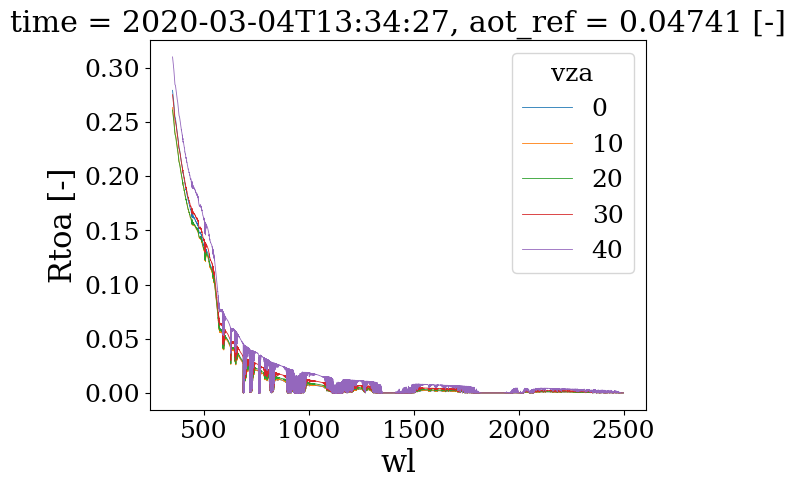

In [15]:
radoc_process.radcalnet_db.Rtoa.isel(time=0).plot(hue='vza',lw=0.6)
plt.show()

In [ ]:
self = radoc_process
self.Tra_d * self.Tg_d * self.E0

In [ ]:
xr.DataArray(vza,coords={'vza':vza},dims='vza')

In [ ]:
radoc_process.execute(aerosol_combination=model.aerosol_combination)
radoc_process.radcalnet_db

In [19]:


radcalnet_db_full =  xr.open_mfdataset(glob.glob(opj(odir,'full_spectral',site, site + '_radcalnet-oc_' + level + '_*_full_spectral.nc')))

radcalnet_db_full

<xarray.Dataset> Size: 33GB
Dimensions:              (time: 3661, wl: 21532, vza: 5, azi: 5, model: 6)
Coordinates:
  * time                 (time) datetime64[ns] 29kB 2017-01-01T08:47:49 ... 2...
  * wl                   (wl) float64 172kB 350.1 350.3 ... 2.499e+03 2.5e+03
    aot_ref              (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
  * vza                  (vza) int64 40B 0 10 20 30 40
  * azi                  (azi) int64 40B 0 45 90 135 180
  * model                (model) <U9 216B 'ARCT_rh70' 'COAV_rh70' ... 'WASO_rh0'
    sza                  (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
Data variables: (12/14)
    Ed                   (time, wl) float64 631MB dask.array<chunksize=(105, 21532), meta=np.ndarray>
    Ratm                 (time, wl, vza, azi) float64 16GB dask.array<chunksize=(105, 21532, 5, 5), meta=np.ndarray>
    Rrs                  (time, wl) float64 631MB dask.array<chunksize=(105, 21532), meta=np.ndarray>
    E0                   (time, wl) float64 631MB dask.array<chunksize=(105, 21532), meta=np.ndarray>
    Rtoa                 (time, wl, vza, azi) float64 16GB dask.array<chunksize=(105, 21532, 5, 5), meta=np.ndarray>
    tcwv                 (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
    ...                   ...
    pressure             (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
    aot550               (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
    aot865               (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
    ang_exp              (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>
    aerosol_combination  (time, model) float64 176kB dask.array<chunksize=(105, 6), meta=np.ndarray>
    D2                   (time) float64 29kB dask.array<chunksize=(105,), meta=np.ndarray>

In [20]:


fwhm=3
central_wl = np.arange(350,2500,1)
spectral=radoc.Spectral(central_wl,fwhm)

start_date='2017-01-01'
end_date='2024-10-31'
radcalnet_db_sub = radcalnet_db_full.sel(time=slice(start_date,end_date))
for year, ds_ in radcalnet_db_sub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):        
       
        filename = opj(odir,'integrated',site, site + '_radcalnet-oc_' + level + '_' + f'{year}_{month:02}'+'_integrated.nc')
        if os.path.exists(filename):
            continue
        odir_ = os.path.dirname(filename)
        if not os.path.exists(odir_):
            os.makedirs(odir_)
            
        radcalnet_db_int = []
        for var_name, values in ds__.items():
            print(var_name)
            if 'wl' in values.dims:
                if 'Rrs' in var_name:
                    radcalnet_db_int.append(values.interp(wl=central_wl))
                else:
                    radcalnet_db_int.append(spectral.convolve2(values,expon=3))
            else:
                radcalnet_db_int.append(values)
        radcalnet_db_int = xr.merge(radcalnet_db_int)
        radcalnet_db_int.to_netcdf(filename)

Ed
Ratm


TypingError: Failed in nopython mode pipeline (step: nopython frontend)
[1m[1m[1mNo implementation of function Function(<built-in function setitem>) found for signature:
 
 >>> setitem(array(float32, 1d, C), int64, array(float64, 2d, C))
 
There are 16 candidate implementations:
[1m  - Of which 16 did not match due to:
  Overload of function 'setitem': File: <numerous>: Line N/A.
    With argument(s): '(array(float32, 1d, C), int64, array(float64, 2d, C))':[0m
[1m   No match.[0m
[0m
[0m[1mDuring: typing of setitem at /home/harmel/Dropbox/Dropbox/work/git/vrtc/radcalnet_oc/radcalnet_oc/lut.py (481)[0m
[1m
File "../radcalnet_oc/lut.py", line 481:[0m
[1m    def convolve2_(
        <source elided>

[1m            response[ii] = np.trapezoid((signal_ * rsr), wl_signal_) / np.trapezoid(rsr, wl_signal_)
[0m            [1m^[0m[0m

[0m[1mDuring: Pass nopython_type_inference[0m

In [ ]:


fwhm=10
central_wl = np.arange(350,2500,10)
spectral=radoc.Spectral(central_wl,fwhm)

start_date='2017-01-01'
end_date='2024-10-31'
radcalnet_db_sub = radcalnet_db_full.sel(time=slice(start_date,end_date))
for year, ds_ in radcalnet_db_sub.groupby('time.year'):
    for month, ds__ in ds_.groupby('time.month'):        
       
        filename = opj(odir,'radcalnet',site, site + '_radcalnet-oc_' + level + '_' + f'{year}_{month:02}'+'_inc10nm_res10nm.nc')
        if os.path.exists(filename):
            continue
        odir_ = os.path.dirname(filename)
        if not os.path.exists(odir_):
            os.makedirs(odir_)
            
        radcalnet_db_int = []
        for var_name, values in ds__.items():
            print(var_name)
            if 'wl' in values.dims:
                if 'Rrs' in var_name:
                    radcalnet_db_int.append(values.interp(wl=central_wl))
                else:
                    radcalnet_db_int.append(spectral.convolve2(values,expon=3))
            else:
                radcalnet_db_int.append(values)
        radcalnet_db_int = xr.merge(radcalnet_db_int)
        radcalnet_db_int.to_netcdf(filename)

# format daily files

In [ ]:
radcalnet_db_full =  xr.open_mfdataset(glob.glob(opj(odir,'full_spectral',site, site + '_radcalnet-oc_' + level + '_*_full_spectral.nc')))

radcalnet_db_full

In [ ]:
radcalnet_db_sub.load()

In [ ]:



fwhm=10
central_wl = np.arange(350,2500,10)
spectral=radoc.Spectral(central_wl,fwhm)

start_date = dt.date(2017, 1, 1)
end_date = dt.date(2024, 12, 31)

# delta time
delta = dt.timedelta(days=1)

# iterate over range of dates
while (start_date <= end_date):
    print(start_date, end="\n")
    date = start_date.strftime('%Y-%m-%d')
    year,month,day=date.split('-')
    
    try:
        radcalnet_db_sub = radcalnet_db_full.sel(time=date)
    except:
        print('no data for '+date)
        start_date += delta
        continue
        
    start_date += delta 

    if len(radcalnet_db_sub.time) == 0:
        continue
    
    filename = opj(odir,'radcalnet',site, year,month,day, site + '_radcalnet-oc_' + level + '_' + date.replace('-','')+'_inc10nm_res10nm.nc')
    if os.path.exists(filename):
        continue
    odir_ = os.path.dirname(filename)
    if not os.path.exists(odir_):
        os.makedirs(odir_)
        
    radcalnet_db_int = []
    for var_name, values in radcalnet_db_sub.items():
        print(var_name)
        if 'wl' in values.dims:
            if 'Rrs' in var_name:
                radcalnet_db_int.append(values.interp(wl=central_wl))
            else:
                radcalnet_db_int.append(spectral.convolve2(values,expon=3))
        else:
            radcalnet_db_int.append(values)
    radcalnet_db_int = xr.merge(radcalnet_db_int)
    radcalnet_db_int.to_netcdf(filename)
    #break
 

In [ ]:
odir

In [ ]:
fig, ax = plt.subplots(ncols=1,nrows=1, figsize=(14, 5))
colors=['g','r','b']
for ii, model_name in enumerate(["WASO_rh0","DESE_rh70","MACL_rh70"]):
    model.aerosol_combination.sel(model=model_name).plot(c=colors[ii],marker='o',ms=3,label=model_name,ax=ax)
plt.legend()
plt.title('')

In [ ]:
cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=0, vmax=0.4)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)


fig,axs = plt.subplots(2,2,figsize=(17,14))   
fig.subplots_adjust(hspace=0.25, wspace=0.3)
for sza,group in radoc_process.radcalnet_db.isel(time=slice(0,25)).squeeze().groupby('sza'):
    
    color=group.aot550.values    
    for ii,wl_range in enumerate([slice(350,2500),slice(400,1000)]):
        group['Rtoa'].sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=1,ls='-',alpha=0.4,ax=axs[ii,0])
        (group['Rtoa']*group['E0']/np.pi).sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=0.5,ls='-',alpha=0.4,ax=axs[ii,1])
    
for ax in  axs.ravel():
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel('')
    ax.set_title('')
    ax.minorticks_on() 
for ii in range(2):
    axs[ii,0].set_ylabel(r'$R_{TOA}\ (-)$')
    axs[ii,1].set_ylabel(r'$L_{TOA}\ (mW\cdot m^{-2}\cdot sr^{-1}\cdot nm^{-1})$')
    
  
ax=axs[0,0]
#ax.text(1.1, 1.1, r'$SZA <40\degree$', fontsize=24, verticalalignment='top', horizontalalignment='center',
#                transform=ax.transAxes)
ax=axs[1,0]
#ax.text(1.1, 1.1, r'$SZA \geq40\degree$', fontsize=24, verticalalignment='top', horizontalalignment='center',
#                transform=ax.transAxes)
cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.05, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)
plt.show()

In [ ]:
cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=0, vmax=0.4)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

wl_range=slice(1600,2250)



fig,axs = plt.subplots(2,2,figsize=(17,14))   
fig.subplots_adjust(hspace=0.25, wspace=0.3)
for sza,group in radoc_process.radcalnet_db.squeeze().groupby('sza'):
    
    color=group.aot550.values    
    for ii,wl_range in enumerate([slice(800,1300),slice(1600,2200)]):
        group['Rtoa'].sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=1,ls='-',alpha=0.4,ax=axs[ii,0])
        (group['Rtoa']*group['E0']/np.pi).sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=0.5,ls='-',alpha=0.4,ax=axs[ii,1])
    
for ax in  axs.ravel():
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel('')
    ax.set_title('')
    ax.minorticks_on() 
for ii in range(2):
    axs[ii,0].set_ylabel(r'$R_{TOA}\ (-)$')
    axs[ii,1].set_ylabel(r'$L_{TOA}\ (mW\cdot m^{-2}\cdot sr^{-1}\cdot nm^{-1})$')
    
  
ax=axs[0,0]
#ax.text(1.1, 1.1, r'$SZA <40\degree$', fontsize=24, verticalalignment='top', horizontalalignment='center',
#                transform=ax.transAxes)
ax=axs[1,0]
#ax.text(1.1, 1.1, r'$SZA \geq40\degree$', fontsize=24, verticalalignment='top', horizontalalignment='center',
#                transform=ax.transAxes)
cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.05, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)
plt.show()

In [ ]:
cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=0, vmax=0.4)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

wl_range=slice(400,1000)



fig,axs = plt.subplots(2,2,figsize=(17,14))   
fig.subplots_adjust(hspace=0.25, wspace=0.3)
for sza,group in radoc_process.radcalnet_db.squeeze().groupby('sza'):
    
    color=group.aot550.values    
    for ii,wl_range in enumerate([slice(350,2500),slice(400,1000)]):
        group['Rtoa'].sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=1,ls='-',alpha=0.4,ax=axs[ii,0])
        (group['Rtoa']*group['E0']/np.pi).sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=0.5,ls='-',alpha=0.4,ax=axs[ii,1])
    
for ax in  axs.ravel():
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel('')
    ax.set_title('')
    ax.minorticks_on() 
for ii in range(2):
    axs[ii,0].set_ylabel(r'$R_{TOA}\ (-)$')
    axs[ii,1].set_ylabel(r'$L_{TOA}\ (mW\cdot m^{-2}\cdot sr^{-1}\cdot nm^{-1})$')
    
  
ax=axs[0,0]
#ax.text(1.1, 1.1, r'$SZA <40\degree$', fontsize=24, verticalalignment='top', horizontalalignment='center',
#                transform=ax.transAxes)
ax=axs[1,0]
#ax.text(1.1, 1.1, r'$SZA \geq40\degree$', fontsize=24, verticalalignment='top', horizontalalignment='center',
#                transform=ax.transAxes)
cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.05, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)
plt.show()

In [ ]:
fwhm=3
central_wl = np.arange(350,2500,1)
spectral=radoc.Spectral(central_wl,fwhm)
Rtoa = spectral.convolve2(radoc_process.radcalnet_db['Rtoa'].load().squeeze(),expon=3).squeeze()

In [ ]:

radoc_process.radcalnet_db.squeeze().to_netcdf('/data/radcalnet/venise_test.nc')

In [ ]:
fwhm=3
central_wl = np.arange(350,2500,1)
spectral=radoc.Spectral(central_wl,fwhm)
radcalnet_db_int = []
for var_name, values in radoc_process.radcalnet_db.items():
    print(var_name)
    if 'wl' in values.dims:
        if 'Rrs' in var_name:
            radcalnet_db_int.append(values.interp(wl=central_wl))
        else:
            radcalnet_db_int.append(spectral.convolve2(values,expon=3))
    else:
        radcalnet_db_int.append(values)
radcalnet_db_int = xr.merge(radcalnet_db_int)

In [ ]:
radcalnet_db_int.to_netcdf('/data/radcalnet/venise_int_test.nc')

In [ ]:
cmap = plt.cm.Spectral_r
norm = mpl.colors.Normalize(vmin=0, vmax=0.4)
sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)

wl_range=slice(400,1000)

fig,axs = plt.subplots(1,2,figsize=(17,7))   
fig.subplots_adjust(hspace=0.25, wspace=0.3)
for sza,group in radcalnet_db_int.groupby('sza'):
    
    color=group.aot550.values      
    Rtoa_ = group.Rtoa.sel(time=group.time.values)
    for ii,wl_range in enumerate([slice(350,2500),slice(440,1000)]):    
        Rtoa_.sel(wl=wl_range).plot(x='wl',color=cmap(norm(color)),lw=1,ls='-',alpha=0.4,ax=axs[ii])
        
       
for ax in  axs.ravel():
    ax.set_xlabel(r'$Wavelength\ (nm)$')
    ax.set_ylabel('')
    ax.set_title('')
    ax.minorticks_on() 
for ii in range(2):
    axs[ii].set_ylabel(r'$R_{TOA}\ (-)$')
    #axs[ii,1].set_ylabel(r'$L_{TOA}\ (mW\cdot m^{-2}\cdot sr^{-1}\cdot nm^{-1})$')
    
 
cb = fig.colorbar(sm, ax=axs[:], shrink=0.6, aspect=35, pad=0.05, location='top')
cb.set_label(r'$AOT(550nm)$', fontsize=22)
plt.show()
